In [14]:
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANNOTATION = Path(
    "Output_files/official_57_sample/annotated.gtf.gz"
)

SAMPLE_SUMMARY = Path(
    "Output_files/official_57_sample/sample_expression_summary.tsv"
)

OUT_DIR = Path(
    "Output_files/official_57_sample"
)

FIG_DIR = Path("Figures")

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = [
    "SRR6713217",
    "SRR6713218"
]

EXPECTED_SAMPLES = 57

In [15]:
def read_annotation(path):

    samples = []
    db_reads = {}
    header_line = None

    with gzip.open(path, "rt") as f:

        for i, line in enumerate(f):

            if (
                line.startswith("##[SAMPLE]")
                and not line.startswith("##[SAMPLE]Sample")
            ):
                sample = (
                    line
                    .replace("##[SAMPLE]", "")
                    .split("\t")[0]
                    .strip()
                )
                samples.append(sample)

            elif line.startswith("##[DBINFO]"):

                text = line.replace(
                    "##[DBINFO]", ""
                ).strip()

                for item in text.split(","):
                    name, value = item.rsplit(":", 1)
                    db_reads[name] = int(value)

            elif line.startswith("#chrom\t"):
                header_line = i
                break

    if header_line is None:
        raise ValueError("No #chrom header found")

    table = pd.read_csv(
        path,
        sep="\t",
        skiprows=header_line,
        low_memory=False
    )

    table = table.rename(
        columns={"#chrom": "chrom"}
    )

    # Keep only names that really exist as columns
    samples = [
        s for s in samples
        if s in table.columns
    ]

    return table, samples, db_reads

In [16]:
table, native_samples, db_reads = read_annotation(
    ANNOTATION
)

print("Transcripts:", len(table))
print("Native sample columns:", len(native_samples))

Transcripts: 102140
Native sample columns: 59


In [17]:
samples = [
    s for s in native_samples
    if s not in EXCLUDE
]

print("RNA-seq samples retained:", len(samples))

assert len(samples) == EXPECTED_SAMPLES

RNA-seq samples retained: 57


In [18]:
sample_summary = pd.read_csv(
    SAMPLE_SUMMARY,
    sep="\t"
)

required = [
    "sample",
    "detected_transcripts",
    "summed_cpm",
    "total_read_count",
    "total_fsm_count",
    "total_em_count"
]

missing = [
    x for x in required
    if x not in sample_summary.columns
]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

sample_summary = (
    sample_summary
    .set_index("sample")
    .loc[samples]
    .reset_index()
)

display(sample_summary.head())

,sample,detected_transcripts,summed_cpm,total_read_count,total_fsm_count,total_em_count
0,SRR17660891,14544,9.999965e+05,1.635869e+06,704486.0,931382.931086
1,SRR17660893,11620,1.000000e+06,8.233124e+05,356636.0,466676.408405
2,SRR17660908,8603,9.999975e+05,2.924568e+05,137835.0,154621.755769
3,SRR17660909,10930,9.999980e+05,3.193136e+05,77331.0,241982.608484
4,SRR17660910,8434,9.999965e+05,1.783552e+05,19059.0,159296.215053


In [19]:
n_transcripts = len(table)
n_samples = len(samples)

presence = np.zeros(
    (n_transcripts, n_samples),
    dtype=bool
)

cpm = np.zeros(
    (n_transcripts, n_samples)
)

counts = np.zeros(
    (n_transcripts, n_samples)
)

fsm = np.zeros(
    (n_transcripts, n_samples)
)

In [20]:
for j, sample in enumerate(samples):

    values = (
        table[sample]
        .astype(str)
        .str.split(":", expand=True)
        .iloc[:, :6]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy()
    )

    cpm[:, j] = values[:, 0]

    counts[:, j] = values[:, 1]

    fsm[:, j] = values[:, 3]

    em_count = values[:, 5]

    # Transcript is present if any evidence exists
    presence[:, j] = (
        (counts[:, j] > 0)
        | (fsm[:, j] > 0)
        | (em_count > 0)
    )

In [21]:
support = presence.sum(axis=1)

population_frequency = (
    support / n_samples
)

read_support = counts.sum(axis=1)

fsm_support = fsm.sum(axis=1)

mean_cpm = cpm.mean(axis=1)

In [22]:
summary = pd.DataFrame({

    "transcript_id":
        table["trans_id"]
        if "trans_id" in table
        else table.index.astype(str),

    "positive_samples":
        support,

    "population_frequency":
        population_frequency,

    "total_read_support":
        read_support,

    "total_fsm_support":
        fsm_support,

    "mean_cpm":
        mean_cpm
})

display(summary.head())

,transcript_id,positive_samples,population_frequency,total_read_support,total_fsm_support,mean_cpm
0,ENSPTRT00045018136,0,0.0,0.0,0.0,0.0
1,ENSPTRT00045018131,0,0.0,0.0,0.0,0.0
2,ENSPTRT00045018135,0,0.0,0.0,0.0,0.0
3,ENSPTRT00045019377,0,0.0,0.0,0.0,0.0
4,ENSPTRT00045019383,0,0.0,0.0,0.0,0.0


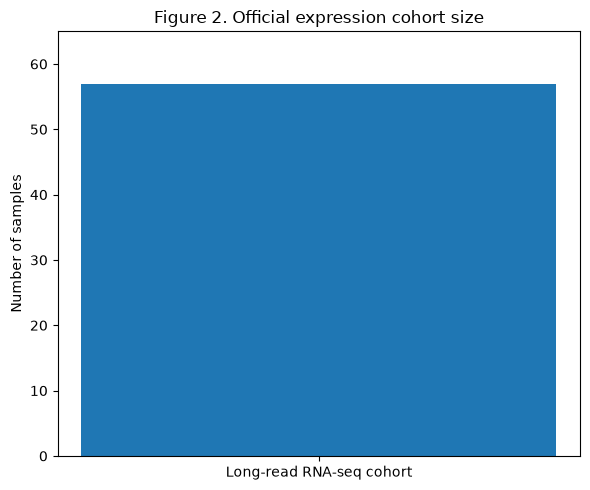

In [23]:
plt.figure(figsize=(6, 5))

plt.bar(
    ["Long-read RNA-seq cohort"],
    [len(sample_summary)]
)

plt.ylabel("Number of samples")
plt.title("Figure 2. Official expression cohort size")

plt.ylim(0, 65)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_02_cohort_size.png",
    dpi=300
)

plt.show()

In [24]:
fsm_total = (
    sample_summary["total_fsm_count"].sum()
)

em_total = (
    sample_summary["total_em_count"].sum()
)

evidence = pd.Series({
    "FSM read support": fsm_total,
    "EM read support": em_total
})

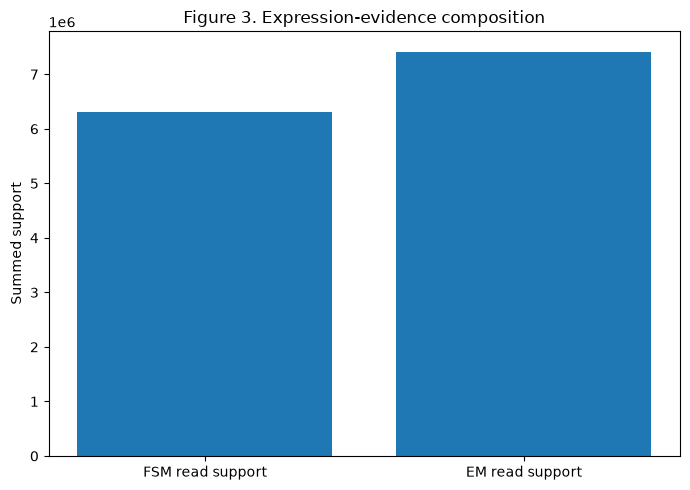

In [25]:
plt.figure(figsize=(7, 5))

plt.bar(
    evidence.index,
    evidence.values
)

plt.ylabel("Summed support")
plt.title(
    "Figure 3. Expression-evidence composition"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_03_expression_evidence.png",
    dpi=300
)

plt.show()

In [26]:
depth = (
    sample_summary[
        ["sample", "total_read_count"]
    ]
    .sort_values("total_read_count")
)

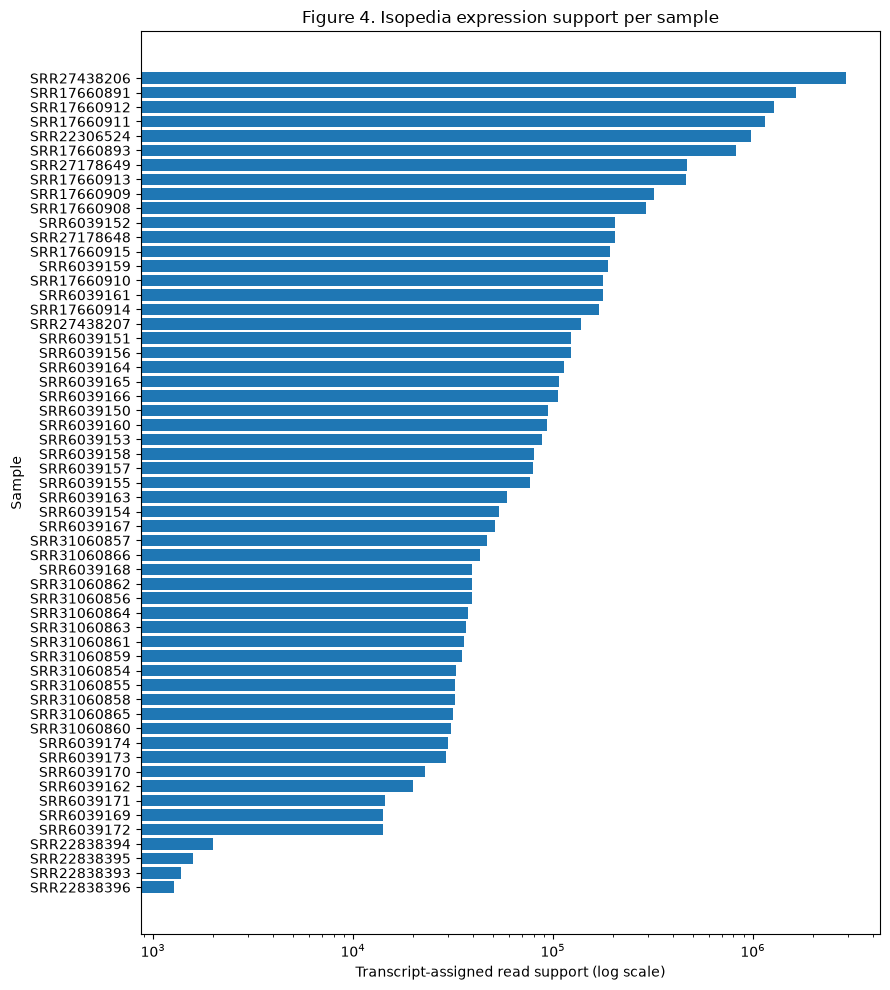

In [27]:
plt.figure(figsize=(9, 10))

plt.barh(
    depth["sample"],
    depth["total_read_count"]
)

plt.xscale("log")

plt.xlabel(
    "Transcript-assigned read support (log scale)"
)

plt.ylabel("Sample")

plt.title(
    "Figure 4. Isopedia expression support per sample"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_04_reads_per_sample.png",
    dpi=300
)

plt.show()

In [28]:
prevalence_counts = np.bincount(
    support,
    minlength=n_samples + 1
)

x = (
    np.arange(n_samples + 1)
    / n_samples
)

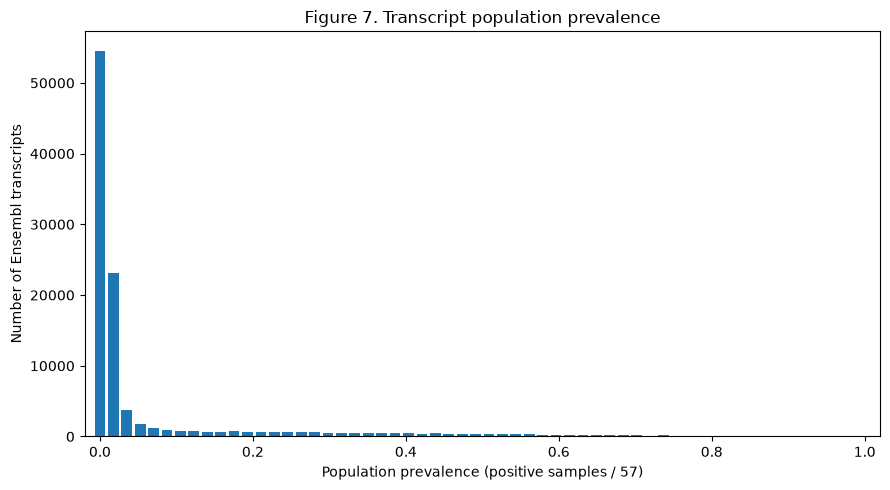

In [29]:
plt.figure(figsize=(9, 5))

plt.bar(
    x,
    prevalence_counts,
    width=0.8 / n_samples
)

plt.xlabel(
    "Population prevalence (positive samples / 57)"
)

plt.ylabel(
    "Number of Ensembl transcripts"
)

plt.title(
    "Figure 7. Transcript population prevalence"
)

plt.xlim(-0.02, 1.02)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_07_isoform_prevalence.png",
    dpi=300
)

plt.show()

In [30]:
def frequency_class(count):

    if count == 0:
        return "Not detected"

    if count == 1:
        return "Singleton"

    fraction = count / n_samples

    if fraction < 0.10:
        return "Rare (<10%)"

    if fraction < 0.25:
        return "Low (10–25%)"

    if fraction < 0.50:
        return "Intermediate (25–50%)"

    if fraction <= 0.90:
        return "Common (50–90%)"

    return "Core (>90%)"

In [31]:
summary["frequency_class"] = [
    frequency_class(int(x))
    for x in support
]

order = [
    "Not detected",
    "Singleton",
    "Rare (<10%)",
    "Low (10–25%)",
    "Intermediate (25–50%)",
    "Common (50–90%)",
    "Core (>90%)"
]

class_counts = (
    summary["frequency_class"]
    .value_counts()
    .reindex(order, fill_value=0)
)

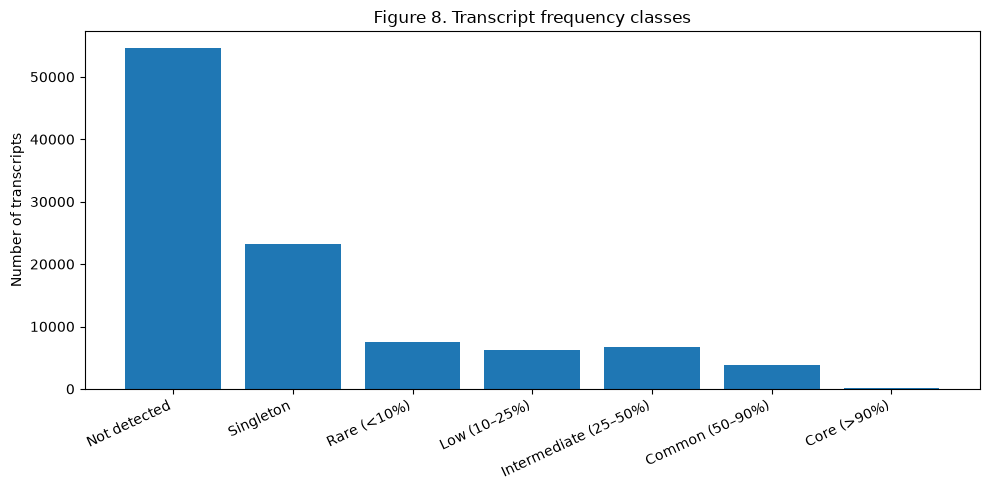

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.ylabel(
    "Number of transcripts"
)

plt.title(
    "Figure 8. Transcript frequency classes"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_08_frequency_classes.png",
    dpi=300
)

plt.show()

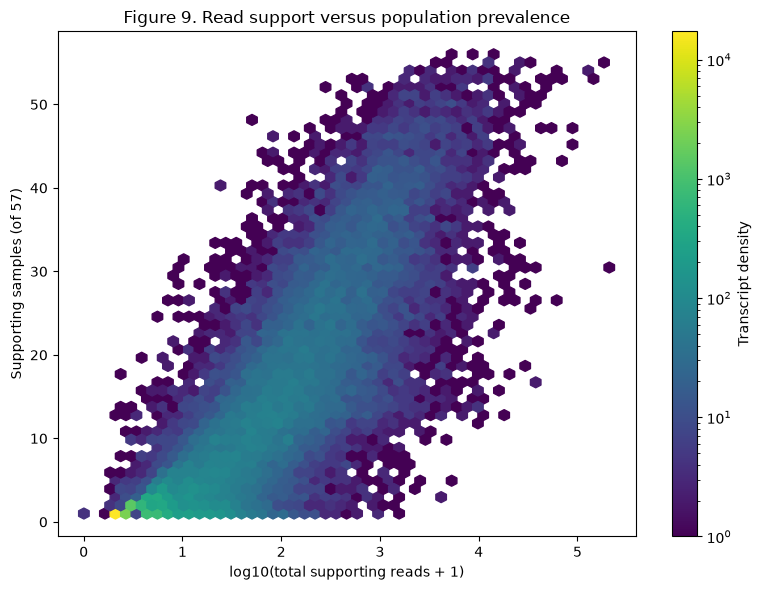

In [35]:
detected = read_support > 0

plt.figure(figsize=(8, 6))

plt.hexbin(
    np.log10(
        read_support[detected] + 1
    ),
    support[detected],
    gridsize=50,
    mincnt=1,
    bins="log"
)

plt.colorbar(
    label="Transcript density"
)

plt.xlabel(
    "log10(total supporting reads + 1)"
)

plt.ylabel(
    "Supporting samples (of 57)"
)

plt.title(
    "Figure 9. Read support versus population prevalence"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_09_prevalence_vs_read_support.png",
    dpi=300
)

plt.show()

In [36]:
selected = []

fraction = support / n_samples

bands = [
    support == 1,
    (support > 1) & (fraction < 0.10),
    (fraction >= 0.10) & (fraction < 0.25),
    (fraction >= 0.25) & (fraction < 0.50),
    fraction >= 0.50
]

for mask in bands:

    candidates = np.where(mask)[0]

    if len(candidates) == 0:
        continue

    # Top 8 by read support
    top = candidates[
        np.argsort(
            read_support[candidates]
        )[-8:]
    ]

    selected.extend(top.tolist())

selected = np.unique(selected)

print(
    "Representative transcripts:",
    len(selected)
)

Representative transcripts: 40


In [37]:
matrix = presence[selected].astype(int)

labels = (
    table.iloc[selected]["trans_id"].astype(str)
    if "trans_id" in table
    else pd.Series(selected.astype(str))
)

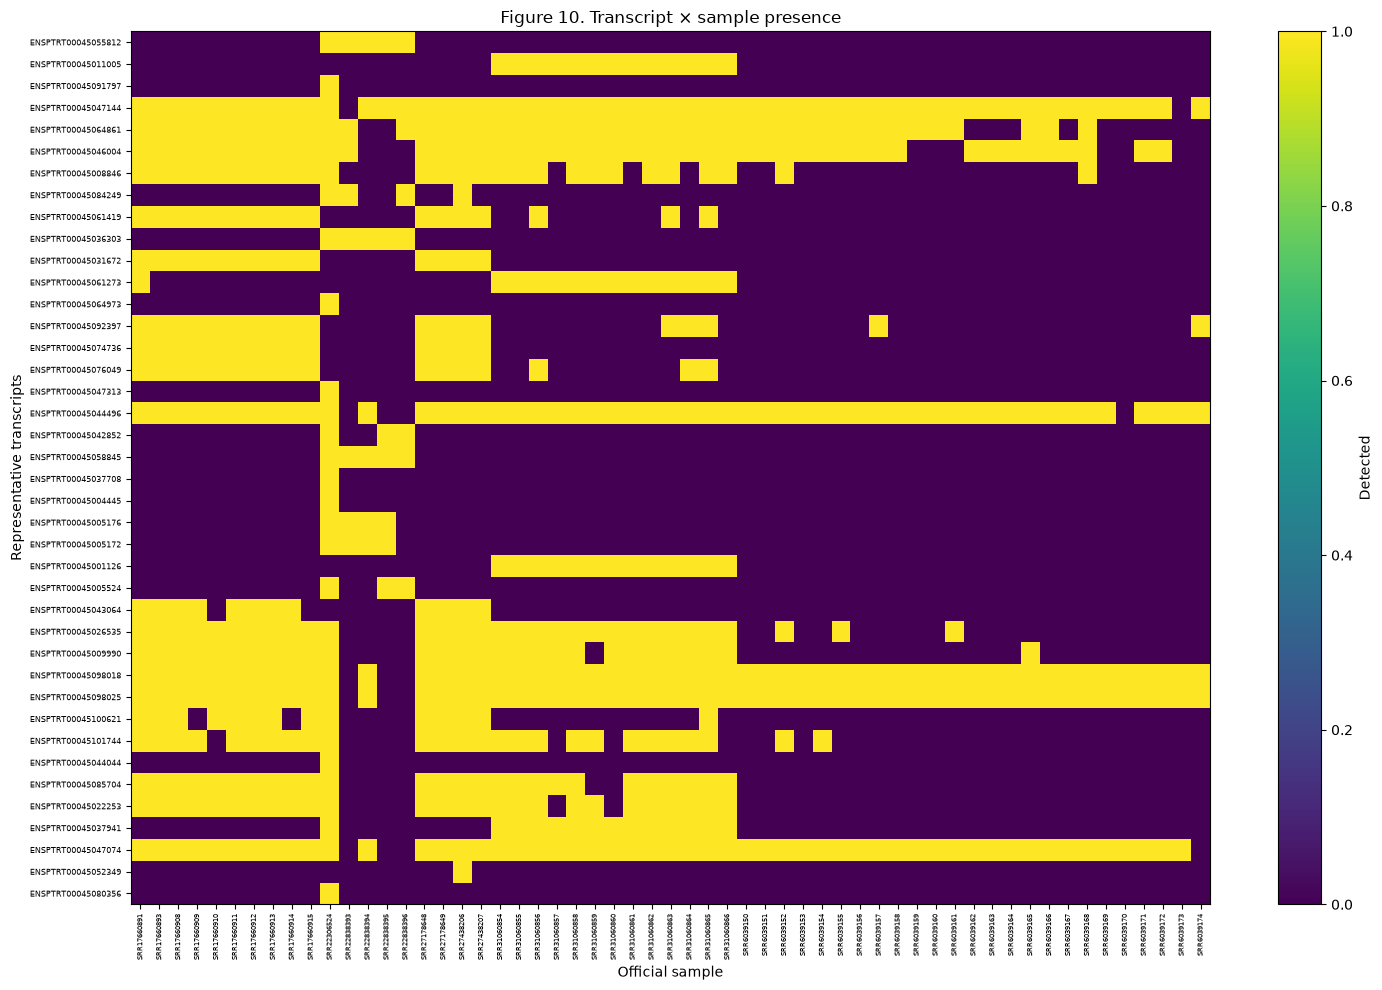

In [38]:
plt.figure(
    figsize=(
        15,
        max(8, len(selected) * 0.25)
    )
)

plt.imshow(
    matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(n_samples),
    samples,
    rotation=90,
    fontsize=5
)

plt.yticks(
    range(len(selected)),
    labels,
    fontsize=6
)

plt.xlabel("Official sample")

plt.ylabel(
    "Representative transcripts"
)

plt.title(
    "Figure 10. Transcript × sample presence"
)

plt.colorbar(
    label="Detected"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_10_sample_presence.png",
    dpi=300
)

plt.show()

In [39]:
diversity = (
    sample_summary[
        ["sample", "detected_transcripts"]
    ]
    .sort_values("detected_transcripts")
)

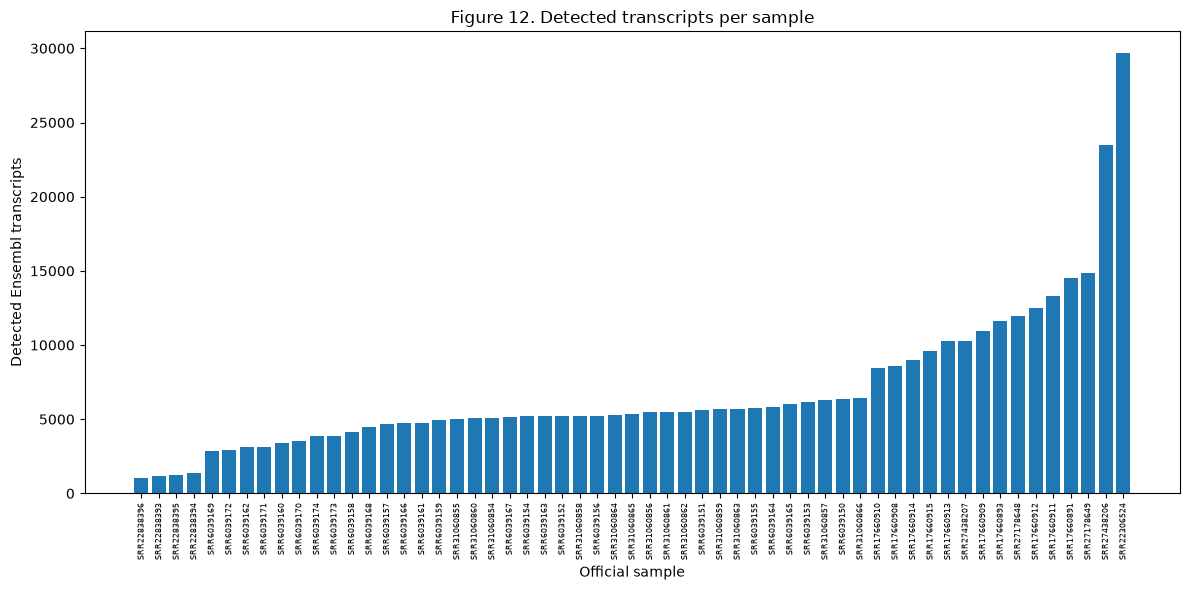

In [40]:
plt.figure(figsize=(12, 6))

plt.bar(
    diversity["sample"],
    diversity["detected_transcripts"]
)

plt.xlabel("Official sample")

plt.ylabel(
    "Detected Ensembl transcripts"
)

plt.title(
    "Figure 12. Detected transcripts per sample"
)

plt.xticks(
    rotation=90,
    fontsize=6
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_12_transcripts_per_sample.png",
    dpi=300
)

plt.show()

In [41]:
N_PERMUTATIONS = 500

rng = np.random.default_rng(
    20260827
)

curves = np.zeros(
    (
        N_PERMUTATIONS,
        n_samples
    )
)

In [42]:
for p in range(N_PERMUTATIONS):

    discovered = np.zeros(
        n_transcripts,
        dtype=bool
    )

    order = rng.permutation(
        n_samples
    )

    for step, sample_index in enumerate(order):

        discovered |= presence[
            :,
            sample_index
        ]

        curves[
            p,
            step
        ] = discovered.sum()

In [43]:
mean_curve = curves.mean(axis=0)

lower = np.percentile(
    curves,
    2.5,
    axis=0
)

upper = np.percentile(
    curves,
    97.5,
    axis=0
)

x = np.arange(
    1,
    n_samples + 1
)

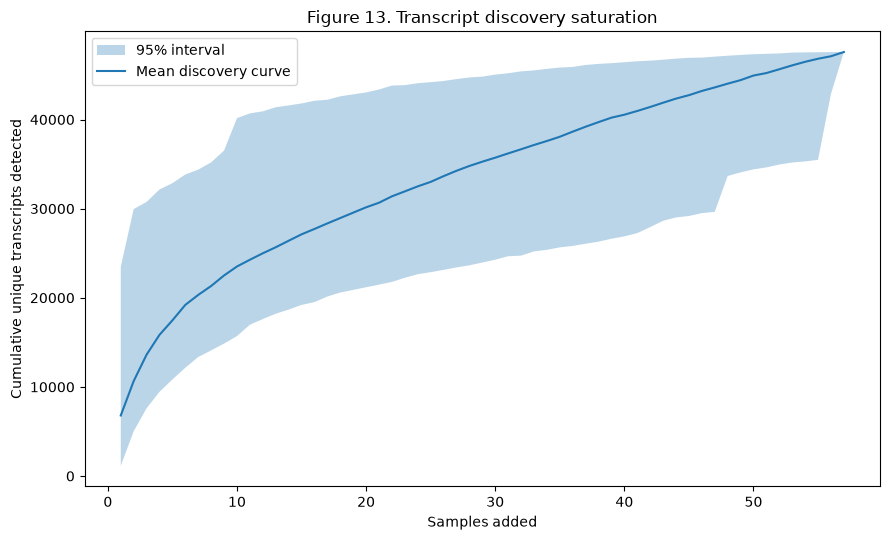

In [44]:
plt.figure(figsize=(9, 5.5))

plt.fill_between(
    x,
    lower,
    upper,
    alpha=0.3,
    label="95% interval"
)

plt.plot(
    x,
    mean_curve,
    label="Mean discovery curve"
)

plt.xlabel(
    "Samples added"
)

plt.ylabel(
    "Cumulative unique transcripts detected"
)

plt.title(
    "Figure 13. Transcript discovery saturation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "Figure_13_saturation.png",
    dpi=300
)

plt.show()

In [45]:
pd.DataFrame({
    "samples_added":
        x,

    "mean_unique_transcripts":
        mean_curve,

    "lower_2.5pct":
        lower,

    "upper_97.5pct":
        upper
}).to_csv(
    OUT_DIR / "Figure_13_data.tsv",
    sep="\t",
    index=False
)

In [46]:
detected_transcripts = int(
    (support > 0).sum()
)

fsm_transcripts = int(
    (fsm.sum(axis=1) > 0).sum()
)

print(
    "Samples:",
    n_samples
)

print(
    "Ensembl transcripts queried:",
    len(table)
)

print(
    "Detected transcripts:",
    detected_transcripts
)

print(
    "Detected fraction:",
    detected_transcripts / len(table)
)

print(
    "Transcripts with FSM evidence:",
    fsm_transcripts
)

print(
    "Total transcript-assigned reads:",
    sample_summary[
        "total_read_count"
    ].sum()
)

print(
    "Unique transcripts at 57 samples:",
    mean_curve[-1]
)

Samples: 57
Ensembl transcripts queried: 102140
Detected transcripts: 47575
Detected fraction: 0.4657822596436264
Transcripts with FSM evidence: 42302
Total transcript-assigned reads: 13717867.859784923
Unique transcripts at 57 samples: 47575.0


In [47]:
summary.to_csv(
    OUT_DIR /
    "figure_transcript_summary.tsv",
    sep="\t",
    index=False
)